# 01 - Data preparation for NMR oil analysis

This notebook prepares the NMR oil dataset for downstream SQL, multivariate statistical and machine-learning analyses.

## Workflow

1. Import libraries. 
2. Load the raw dataset.
3. Inspect its structure and missing values.
4. Detect and remove duplicate analytical records.
5. Identify metadata and NMR variables.
6. Separate samples by oil type.
7. inspect distributions using quantiles.
8. identify potential outliers using Tukey's fences and MAD.
9. impute missing NMR measurements
10. Validate, standarize and save the processed dataset.

## 1. Import libraries

In [24]:
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
import statsmodels as sm
from sklearn.impute import KNNImputer
from pathlib import Path
import matplotlib.pyplot as plt

## 2. Load the raw dataset

In [25]:
data=pd.read_csv('data/raw/oils_nmr.csv')
data.shape

(150, 28)

In [26]:
print(f'Rows: {data.shape[0]}')
print(f'Columns: {data.shape[1]}')

Rows: 150
Columns: 28


In [27]:
pd.set_option('display.max_rows', 150)
pd.set_option('display.max_columns', 150)

data.head()

,Primary ID,Date,Oil type,Manufacturer,Batch number,Spectra number,0.88 ppm,0.89 ppm,0.90 ppm,0.98 ppm,1.31 ppm,1.36 ppm,1.61 ppm,1.68 ppm,2.05 ppm,2.01 ppm,2.19 ppm,2.31 ppm,2.77 ppm,4.14 ppm,4.29 ppm,5.12 ppm,5.26 ppm,5.34 ppm,5.43 ppm,5.69 ppm,6.05 ppm,6.45 ppm
0,1,"October 07, 2025",Amaranth oil,A,43739,1,125.47,15.67,12.34,11.18,5306.83,565.27,837.44,73.93,537.41,526.74,12.03,605.74,289.95,212.43,207.07,6.50,98.21,690.85,15.09,0.17,0.14,0.34
1,2,"October 07, 2025",Amaranth oil,A,43739,2,118.10,12.61,13.60,10.30,4961.43,543.99,798.57,73.89,493.14,559.02,10.17,576.95,278.62,202.45,200.15,6.18,93.73,657.26,14.80,0.16,0.13,0.34
2,3,"October 08, 2025",Amaranth oil,A,43739,3,120.78,14.86,12.87,10.92,5138.00,565.93,828.82,72.39,523.22,511.93,10.83,593.72,288.63,204.00,204.26,6.55,95.49,674.88,16.99,0.23,0.13,0.32
3,4,"October 10, 2025",Amaranth oil,B,43466,4,123.53,13.89,13.74,10.57,5255.57,534.17,828.79,85.30,532.51,511.78,10.76,586.82,281.73,207.87,197.60,NaN,NaN,658.60,14.73,0.13,0.10,NaN
4,5,2025-11-02,Amaranth oil,B,43466,5,131.93,14.88,15.07,11.60,5660.95,594.31,886.85,88.52,570.69,605.27,11.31,621.07,NaN,221.07,210.26,6.17,98.52,702.16,19.60,0.14,0.21,0.22


In [28]:
#data

## 3. Inspect dataset structure

In [29]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 28 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Primary ID      150 non-null    int64  
 1   Date            150 non-null    object 
 2   Oil type        150 non-null    object 
 3   Manufacturer    150 non-null    object 
 4   Batch number    150 non-null    object 
 5   Spectra number  150 non-null    int64  
 6   0.88 ppm        144 non-null    float64
 7   0.89 ppm        150 non-null    float64
 8   0.90 ppm        146 non-null    float64
 9   0.98 ppm        150 non-null    float64
 10  1.31 ppm        150 non-null    float64
 11  1.36 ppm        150 non-null    float64
 12  1.61 ppm        146 non-null    float64
 13  1.68 ppm        150 non-null    float64
 14  2.05 ppm        150 non-null    float64
 15  2.01 ppm        150 non-null    float64
 16  2.19 ppm        150 non-null    float64
 17  2.31 ppm        150 non-null    flo

In [30]:
data.columns

Index(['Primary ID', 'Date', 'Oil type', 'Manufacturer', 'Batch number',
       'Spectra number', '0.88 ppm', '0.89 ppm', '0.90 ppm', '0.98 ppm',
       '1.31 ppm', '1.36 ppm', '1.61 ppm', '1.68 ppm', '2.05 ppm', '2.01 ppm',
       '2.19 ppm', '2.31 ppm', '2.77 ppm', '4.14 ppm', '4.29 ppm', '5.12 ppm',
       '5.26 ppm', '5.34 ppm', '5.43 ppm', '5.69 ppm', '6.05 ppm', '6.45 ppm'],
      dtype='object')

In [31]:
data.describe() #Collect information about attributes distribution (mean, std, 0.25, 0.5, 0.75 quantiles)

,Primary ID,Spectra number,0.88 ppm,0.89 ppm,0.90 ppm,0.98 ppm,1.31 ppm,1.36 ppm,1.61 ppm,1.68 ppm,2.05 ppm,2.01 ppm,2.19 ppm,2.31 ppm,2.77 ppm,4.14 ppm,4.29 ppm,5.12 ppm,5.26 ppm,5.34 ppm,5.43 ppm,5.69 ppm,6.05 ppm,6.45 ppm
count,150.000000,150.000000,144.000000,150.000000,146.00000,150.000000,150.000000,150.000000,146.000000,150.000000,150.000000,150.000000,150.000000,150.000000,142.000000,150.000000,150.000000,133.000000,145.000000,150.000000,150.000000,150.000000,150.000000,96.000000
mean,75.500000,75.500000,104.145833,30.168933,65.11089,9.239133,5108.373867,801.301000,771.408767,30.420133,457.051667,264.294400,346.160467,678.415733,130.925070,235.476733,230.557200,2.972331,108.700138,456.456800,168.796200,8.301067,163.871333,246.848958
std,43.445368,43.445368,50.062506,26.222465,66.66115,2.598623,1409.565243,485.928077,55.522477,35.631576,259.150411,200.116655,479.136081,58.512990,102.503209,20.189702,21.283891,2.394148,9.043899,210.195291,220.068194,11.678916,233.137865,238.468035
min,1.000000,1.000000,30.820000,8.380000,12.33000,2.810000,3103.680000,350.230000,695.020000,3.010000,84.630000,75.200000,6.310000,575.670000,33.520000,201.970000,197.380000,0.380000,93.660000,150.280000,2.360000,0.040000,0.060000,0.110000
25%,38.250000,38.250000,43.390000,9.500000,13.70500,6.192500,3445.857500,374.252500,727.250000,3.797500,127.740000,112.107500,8.975000,616.612500,53.645000,216.675000,206.890000,0.810000,98.590000,208.602500,8.060000,0.090000,0.120000,0.220000
50%,75.500000,75.500000,125.270000,14.850000,22.59000,10.415000,5282.280000,564.380000,753.790000,7.455000,541.595000,153.950000,10.825000,704.705000,86.775000,237.365000,235.120000,1.830000,110.610000,502.710000,16.085000,0.140000,0.190000,442.730000
75%,112.750000,112.750000,139.862500,61.755000,149.90750,11.252500,6503.167500,1424.485000,828.322500,73.920000,690.852500,517.345000,958.842500,714.910000,278.727500,248.325000,244.887500,5.970000,114.910000,662.747500,461.640000,23.147500,462.405000,473.297500
max,150.000000,150.000000,189.040000,78.590000,176.14000,12.670000,7588.300000,1630.960000,887.450000,90.020000,814.550000,607.400000,1141.790000,770.000000,291.940000,290.820000,280.510000,6.770000,130.090000,729.230000,531.570000,28.780000,553.440000,523.940000


In [32]:
data['0.88 ppm'].describe()

count    144.000000
mean     104.145833
std       50.062506
min       30.820000
25%       43.390000
50%      125.270000
75%      139.862500
max      189.040000
Name: 0.88 ppm, dtype: float64

In [33]:
data['0.88 ppm'].mean()

104.14583333333333

### 3.1 Inspect meta data (which columns are unique, which are grouping ones)

In [34]:
data.nunique() == len(data)

Primary ID         True
Date              False
Oil type          False
Manufacturer      False
Batch number      False
Spectra number     True
0.88 ppm          False
0.89 ppm          False
0.90 ppm          False
0.98 ppm          False
1.31 ppm          False
1.36 ppm          False
1.61 ppm          False
1.68 ppm          False
2.05 ppm          False
2.01 ppm          False
2.19 ppm          False
2.31 ppm          False
2.77 ppm          False
4.14 ppm          False
4.29 ppm          False
5.12 ppm          False
5.26 ppm          False
5.34 ppm          False
5.43 ppm          False
5.69 ppm          False
6.05 ppm          False
6.45 ppm          False
dtype: bool

**Note**: Primary ID and Spectra Number are unique

### 3.2 How many measurements were performed for each batch?

In [35]:
batch_counts = (data.groupby(['Oil type', 'Manufacturer', 'Batch number'],dropna=False)
                .agg(number_of_spectra=('Spectra number', 'nunique'))
                .reset_index()
                .sort_values('number_of_spectra', ascending=False))

display(batch_counts)

,Oil type,Manufacturer,Batch number,number_of_spectra
10,Pomegranate oil,A,7997103831,9
3,Amaranth oil,B,43466,8
17,Sea buckthorn oil,A,42767,8
15,Pomegranate oil,D,71/8 10397,8
13,Pomegranate oil,B,7997103831,7
24,Sea buckthorn oil,D,43497,7
22,Sea buckthorn oil,C,43525,7
21,Sea buckthorn oil,C,43497,7
20,Sea buckthorn oil,C,42767,7
7,Amaranth oil,C,43497,7


**Note**: For the majority of combinations of: oil type + Manufacturer + Batch number more than one measurement was performed. 
The number of measurements is not the same for each batch. Some groups are represented by several spectra, while others are represented by only one.

### 3.3 Are there any potential technical replicates?

In [36]:
technical_repeats = (data.groupby('Primary ID', dropna=False)
                    .agg(number_of_spectra=('Spectra number', 'nunique'))
                    .reset_index()
                    .query('number_of_spectra > 1')
                    .sort_values('number_of_spectra', ascending=False))

display(technical_repeats)

,Primary ID,number_of_spectra


**Note**: No potential technical replicates were identified based on Primary ID. Each Primary ID was associated with only one unique spectrum

### 3.4 Are there any repeating metadata combinations?

In [37]:
metadata_columns = ['Date', 'Oil type', 'Manufacturer', 'Batch number']

repeated_metadata = (data.groupby(metadata_columns, dropna=False)
                     .size()
                     .reset_index(name='number_of_records')
                     .query('number_of_records > 1')
                     .sort_values('number_of_records', ascending=False))

display(repeated_metadata)

,Date,Oil type,Manufacturer,Batch number,number_of_records
51,"October 07, 2025",Amaranth oil,A,43739,4
14,03/10/2025,Sea buckthorn oil,C,42767,4
45,2025-11-12,Pomegranate oil,A,7997103831,4
36,2025-11-02,Amaranth oil,B,43466,3
83,"October 10, 2025",Pomegranate oil,A,71/8 10397,3
80,"October 10, 2025",Amaranth oil,B,43466,3
78,"October 08, 2025",Pomegranate oil,D,7997103831,3
71,"October 08, 2025",Amaranth oil,C,43466,3
67,"October 08, 2025",Amaranth oil,A,43466,3
61,"October 07, 2025",Pomegranate oil,B,no data,3


**Note**: Repeated metadata combinations were found, with some combinations occurring two to four times. However, these records have unique Primary IDs and spectrum numbers, so they should not automatically be treated as duplicates.

### 3.5 Are there any identical rows?

In [38]:
exact_duplicates = data[data.duplicated(keep=False)]

print("Number of identical rows:",data.duplicated().sum())
display(exact_duplicates)

Number of identical rows: 0


,Primary ID,Date,Oil type,Manufacturer,Batch number,Spectra number,0.88 ppm,0.89 ppm,0.90 ppm,0.98 ppm,1.31 ppm,1.36 ppm,1.61 ppm,1.68 ppm,2.05 ppm,2.01 ppm,2.19 ppm,2.31 ppm,2.77 ppm,4.14 ppm,4.29 ppm,5.12 ppm,5.26 ppm,5.34 ppm,5.43 ppm,5.69 ppm,6.05 ppm,6.45 ppm


**Note**: There are no completely identical poems in the collection. Therefore, there are no exact duplicates

**Sum up:** The number of spectra per oil-manufacturer-batch combination ranged from 1 to 9. No potential technical replicates were detected because each Primary ID was associated with only one spectrum. Several metadata combinations were repeated two to four times, but these records had unique identifiers and therefore were not considered exact duplicates. No completely identical rows were found in the dataset.

### 3.6 Inspect missing values 

In [39]:
missing_mask= data.isna().sum() >0  
col_with_missing = data.columns[missing_mask]
print("Column names with missing values:",list(col_with_missing))

Column names with missing values: ['0.88 ppm', '0.90 ppm', '1.61 ppm', '2.77 ppm', '5.12 ppm', '5.26 ppm', '6.45 ppm']


In [40]:
print("Number of samples by oil type:")
display(data["Oil type"].value_counts())

print("\nMissing values by column:")
missing_summary = pd.DataFrame({ 
                    "missing_count": data.isna().sum(),
                    "missing_percent": data.isna().mean() * 100}).query("missing_count > 0"
                                                                       ).sort_values("missing_percent", 
                    ascending=False)

missing_summary

Number of samples by oil type:


Oil type
Amaranth oil         50
Pomegranate oil      50
Sea buckthorn oil    50
Name: count, dtype: int64


Missing values by column:


,missing_count,missing_percent
6.45 ppm,54,36.000000
5.12 ppm,17,11.333333
2.77 ppm,8,5.333333
0.88 ppm,6,4.000000
5.26 ppm,5,3.333333
0.90 ppm,4,2.666667
1.61 ppm,4,2.666667


## 4. Detect duplicate analytical records

`Manufacturer`, `Primary ID` and `Spectra number` are excluded before deduplicates because they have unique or irrelevant values ​​that would disrupt row comparisons during duplication.

In [41]:
subset_data=data.drop(columns=['Manufacturer','Primary ID','Spectra number']).columns.tolist()

subset_data

['Date',
 'Oil type',
 'Batch number',
 '0.88 ppm',
 '0.89 ppm',
 '0.90 ppm',
 '0.98 ppm',
 '1.31 ppm',
 '1.36 ppm',
 '1.61 ppm',
 '1.68 ppm',
 '2.05 ppm',
 '2.01 ppm',
 '2.19 ppm',
 '2.31 ppm',
 '2.77 ppm',
 '4.14 ppm',
 '4.29 ppm',
 '5.12 ppm',
 '5.26 ppm',
 '5.34 ppm',
 '5.43 ppm',
 '5.69 ppm',
 '6.05 ppm',
 '6.45 ppm']

In [42]:
complete_metadata = data.dropna(subset=subset_data)

duplicates = complete_metadata[complete_metadata.duplicated(subset=subset_data,keep=False)]

display(duplicates)

,Primary ID,Date,Oil type,Manufacturer,Batch number,Spectra number,0.88 ppm,0.89 ppm,0.90 ppm,0.98 ppm,1.31 ppm,1.36 ppm,1.61 ppm,1.68 ppm,2.05 ppm,2.01 ppm,2.19 ppm,2.31 ppm,2.77 ppm,4.14 ppm,4.29 ppm,5.12 ppm,5.26 ppm,5.34 ppm,5.43 ppm,5.69 ppm,6.05 ppm,6.45 ppm
53,54,"October 07, 2025",Pomegranate oil,A,no data,54,43.39,9.29,150.28,5.45,3446.36,1427.56,736.47,7.46,128.24,112.91,963.53,708.1,54.01,240.66,235.68,1.01,112.54,211.45,462.92,23.21,463.08,456.6
54,55,"October 07, 2025",Pomegranate oil,B,no data,55,43.39,9.29,150.28,5.45,3446.36,1427.56,736.47,7.46,128.24,112.91,963.53,708.1,54.01,240.66,235.68,1.01,112.54,211.45,462.92,23.21,463.08,456.6


In [43]:
print("Original shape:",data.shape)
print("Shape after removing duplicates:",data.drop_duplicates(subset_data).shape)

duplicate_records = data[data.duplicated(subset_data, keep="first")]
duplicate_records

Original shape: (150, 28)
Shape after removing duplicates: (149, 28)


,Primary ID,Date,Oil type,Manufacturer,Batch number,Spectra number,0.88 ppm,0.89 ppm,0.90 ppm,0.98 ppm,1.31 ppm,1.36 ppm,1.61 ppm,1.68 ppm,2.05 ppm,2.01 ppm,2.19 ppm,2.31 ppm,2.77 ppm,4.14 ppm,4.29 ppm,5.12 ppm,5.26 ppm,5.34 ppm,5.43 ppm,5.69 ppm,6.05 ppm,6.45 ppm
54,55,"October 07, 2025",Pomegranate oil,B,no data,55,43.39,9.29,150.28,5.45,3446.36,1427.56,736.47,7.46,128.24,112.91,963.53,708.1,54.01,240.66,235.68,1.01,112.54,211.45,462.92,23.21,463.08,456.6


**Note**: In the subset there is only 1 duplicate

In [44]:
#making deduplication and copy of new data set 
data_v1=data.drop_duplicates(subset=subset_data,keep='first').copy() 

print("Shape of deduplicated dataset:",data_v1.shape)
data_v1.head()

Shape of deduplicated dataset: (149, 28)


,Primary ID,Date,Oil type,Manufacturer,Batch number,Spectra number,0.88 ppm,0.89 ppm,0.90 ppm,0.98 ppm,1.31 ppm,1.36 ppm,1.61 ppm,1.68 ppm,2.05 ppm,2.01 ppm,2.19 ppm,2.31 ppm,2.77 ppm,4.14 ppm,4.29 ppm,5.12 ppm,5.26 ppm,5.34 ppm,5.43 ppm,5.69 ppm,6.05 ppm,6.45 ppm
0,1,"October 07, 2025",Amaranth oil,A,43739,1,125.47,15.67,12.34,11.18,5306.83,565.27,837.44,73.93,537.41,526.74,12.03,605.74,289.95,212.43,207.07,6.50,98.21,690.85,15.09,0.17,0.14,0.34
1,2,"October 07, 2025",Amaranth oil,A,43739,2,118.10,12.61,13.60,10.30,4961.43,543.99,798.57,73.89,493.14,559.02,10.17,576.95,278.62,202.45,200.15,6.18,93.73,657.26,14.80,0.16,0.13,0.34
2,3,"October 08, 2025",Amaranth oil,A,43739,3,120.78,14.86,12.87,10.92,5138.00,565.93,828.82,72.39,523.22,511.93,10.83,593.72,288.63,204.00,204.26,6.55,95.49,674.88,16.99,0.23,0.13,0.32
3,4,"October 10, 2025",Amaranth oil,B,43466,4,123.53,13.89,13.74,10.57,5255.57,534.17,828.79,85.30,532.51,511.78,10.76,586.82,281.73,207.87,197.60,NaN,NaN,658.60,14.73,0.13,0.10,NaN
4,5,2025-11-02,Amaranth oil,B,43466,5,131.93,14.88,15.07,11.60,5660.95,594.31,886.85,88.52,570.69,605.27,11.31,621.07,NaN,221.07,210.26,6.17,98.52,702.16,19.60,0.14,0.21,0.22


## 5. Identify metadata and NMR variables

The NMR columns are the variables whose names contain `ppm`. This keeps the analytical measurements separate from sample metadata.

In [45]:
metadata_columns = ["Primary ID", "Date", "Oil type", "Manufacturer", "Batch number", "Spectra number"]

nmr_columns = [column for column in data_v1.columns if "ppm" in column.lower()]

print("Metadata columns:")
print(metadata_columns)

print(f"\nNumber of NMR variables: {len(nmr_columns)}")
print(nmr_columns)

Metadata columns:
['Primary ID', 'Date', 'Oil type', 'Manufacturer', 'Batch number', 'Spectra number']

Number of NMR variables: 22
['0.88 ppm', '0.89 ppm', '0.90 ppm', '0.98 ppm', '1.31 ppm', '1.36 ppm', '1.61 ppm', '1.68 ppm', '2.05 ppm', '2.01 ppm', '2.19 ppm', '2.31 ppm', '2.77 ppm', '4.14 ppm', '4.29 ppm', '5.12 ppm', '5.26 ppm', '5.34 ppm', '5.43 ppm', '5.69 ppm', '6.05 ppm', '6.45 ppm']


## 6. Split data by oil type

In [46]:
# Split into separate DataFrames by group
grouped_dfs = {group_name: group_data.copy() for group_name, group_data in data_v1.groupby("Oil type")}

print(f"Oil groups: {list(grouped_dfs)}")

data_ao = grouped_dfs["Amaranth oil"]
data_po = grouped_dfs["Pomegranate oil"]
data_sbo = grouped_dfs["Sea buckthorn oil"]

for group_name, group_data in grouped_dfs.items():
    print(f"{group_name}: {group_data.shape[0]} samples")

Oil groups: ['Amaranth oil', 'Pomegranate oil', 'Sea buckthorn oil']
Amaranth oil: 50 samples
Pomegranate oil: 49 samples
Sea buckthorn oil: 50 samples


## 7. Inspect distributions with quantiles

**quantile** - shows the distribution of numerical data in each measurement column, allowing to determine whether the data is evenly distributed and we can check are there high values at the start and end of the column. In this example is used to inspect the range and tails of each NMR variable.

In [47]:
for group_name, group_data in grouped_dfs.items():
    print(f"\n-- {group_name} --")
    display(group_data[nmr_columns].quantile([0.01, 0.05, 0.10, 0.20, 0.50, 0.80, 0.90, 0.95, 0.99, 1.00]).T)


-- Amaranth oil --


,0.01,0.05,0.10,0.20,0.50,0.80,0.90,0.95,0.99,1.00
0.88 ppm,117.8315,118.1075,118.896,120.826,125.270,128.850,131.911,131.9470,132.1211,132.22
0.89 ppm,12.5845,12.6400,13.731,14.352,14.850,14.932,14.970,15.3545,15.6751,15.68
0.90 ppm,12.3349,12.5650,12.867,13.096,13.435,13.750,15.042,15.0700,15.1155,15.14
0.98 ppm,10.2698,10.3090,10.494,10.568,10.930,11.592,11.610,11.6200,11.6353,11.65
1.31 ppm,4960.0177,4964.0940,5114.348,5149.954,5282.280,5401.250,5653.353,5661.2910,5664.8301,5665.08
1.36 ppm,534.1749,534.6360,534.972,536.224,564.380,569.204,594.127,594.6455,595.2393,595.45
1.61 ppm,797.4241,798.6870,812.756,816.936,836.590,852.014,885.953,886.9105,887.2932,887.45
1.68 ppm,72.2982,72.7835,73.040,73.830,78.490,88.384,88.825,89.4735,89.9710,90.02
2.05 ppm,492.8544,494.0590,518.695,524.512,541.595,559.024,570.621,571.0750,572.0210,572.07
2.01 ppm,510.2886,511.0090,511.780,514.396,527.170,562.812,604.878,605.1890,606.4984,607.40



-- Pomegranate oil --


,0.01,0.05,0.10,0.20,0.50,0.80,0.90,0.95,0.99,1.00
0.88 ppm,30.9400,31.316,31.572,32.916,36.84,43.600,43.736,43.766,43.8732,43.95
0.89 ppm,8.3848,8.402,8.440,8.860,9.33,9.768,10.140,10.146,10.1500,10.15
0.90 ppm,147.0860,147.394,147.968,148.508,155.96,164.262,168.212,174.542,175.6072,176.14
0.98 ppm,2.8244,3.318,4.108,5.292,6.01,6.264,8.366,8.556,8.6052,8.61
1.31 ppm,3106.0176,3109.806,3115.784,3155.784,3377.29,3446.388,3451.600,3478.702,3481.3352,3483.14
1.36 ppm,1402.6172,1406.564,1419.934,1421.964,1446.50,1527.892,1570.760,1624.134,1629.7216,1630.96
1.61 ppm,700.4348,701.182,702.930,716.024,735.76,742.360,750.280,772.448,772.8000,772.80
1.68 ppm,5.5496,5.588,5.652,6.278,7.45,8.038,9.642,9.706,9.7352,9.74
2.05 ppm,84.7980,85.364,86.450,90.786,99.94,127.800,128.296,128.606,129.1668,129.33
2.01 ppm,75.3296,75.726,77.146,79.068,90.27,112.250,112.910,113.930,114.3668,114.41



-- Sea buckthorn oil --


,0.01,0.05,0.10,0.20,0.50,0.80,0.90,0.95,0.99,1.00
0.88 ppm,136.5548,136.9585,137.230,139.698,150.545,159.028,170.194,180.4895,188.8440,189.04
0.89 ppm,53.1521,53.3630,60.206,61.116,67.450,72.560,73.388,78.3680,78.5214,78.59
0.90 ppm,14.1140,14.3475,14.520,17.900,22.590,24.190,26.225,26.2600,26.3890,26.47
0.98 ppm,9.6641,9.7245,9.968,10.108,10.445,11.494,11.864,12.2840,12.6406,12.67
1.31 ppm,6313.3065,6337.2245,6358.897,6468.296,6538.695,6995.332,7010.877,7317.0885,7579.5143,7588.30
1.36 ppm,350.5485,351.2785,351.788,352.710,371.880,388.914,391.504,400.2615,407.4669,407.56
1.61 ppm,695.1595,696.1375,697.090,704.830,738.525,771.340,776.680,799.5350,807.3010,807.85
1.68 ppm,3.0198,3.0445,3.069,3.090,3.260,3.884,4.201,4.2960,4.3651,4.37
2.05 ppm,684.6223,686.7545,687.028,688.782,719.785,745.684,749.551,786.0730,814.3589,814.55
2.01 ppm,142.7864,143.1885,143.519,146.820,153.950,159.310,160.670,166.6470,171.8032,171.96


<Figure size 700x400 with 0 Axes>

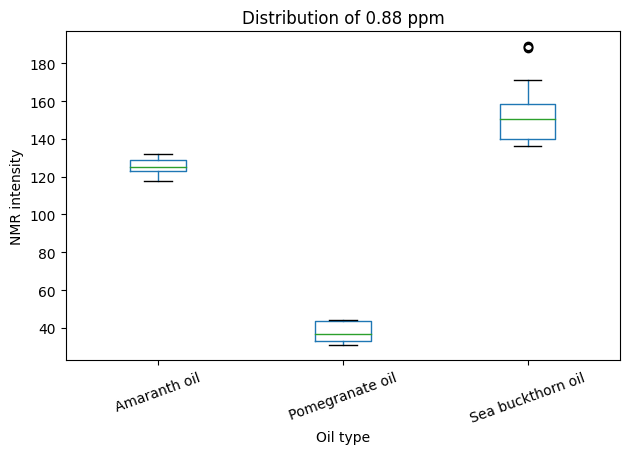

<Figure size 700x400 with 0 Axes>

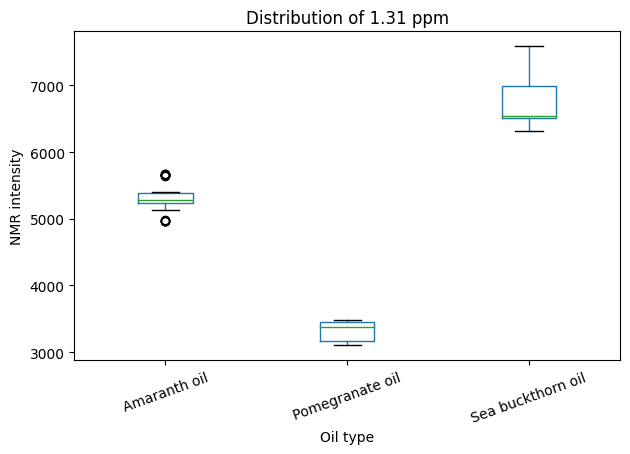

<Figure size 700x400 with 0 Axes>

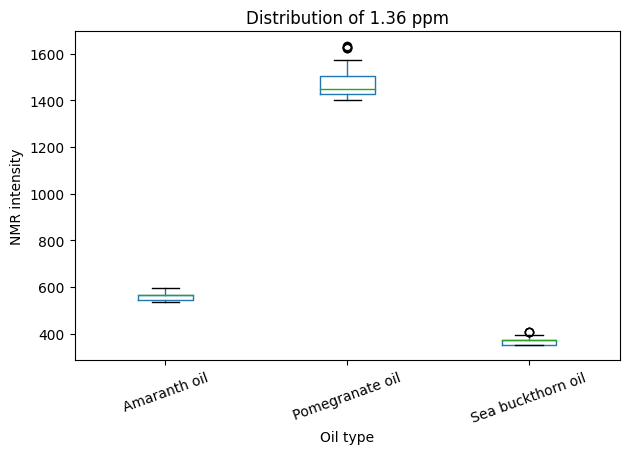

<Figure size 700x400 with 0 Axes>

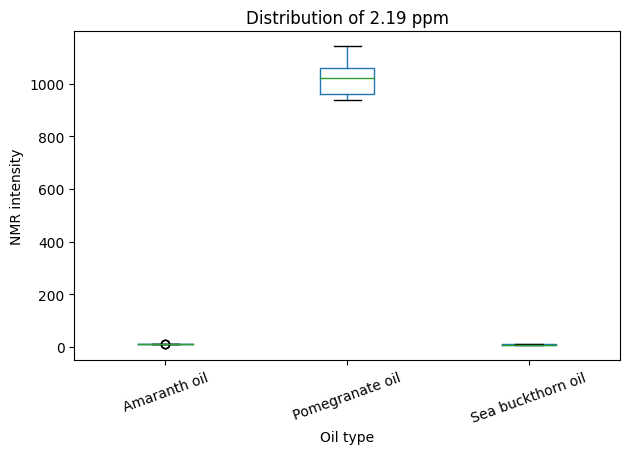

<Figure size 700x400 with 0 Axes>

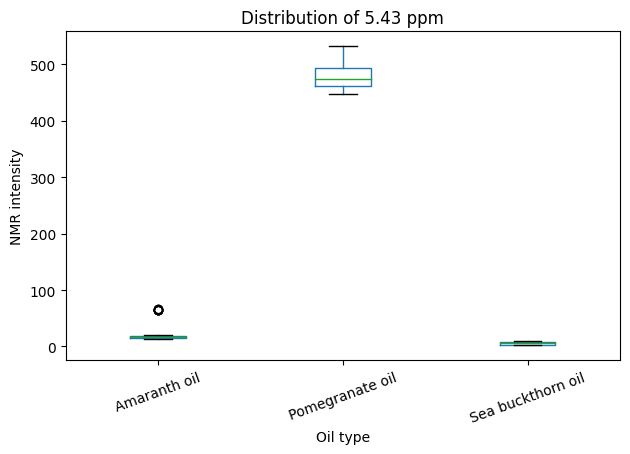

<Figure size 700x400 with 0 Axes>

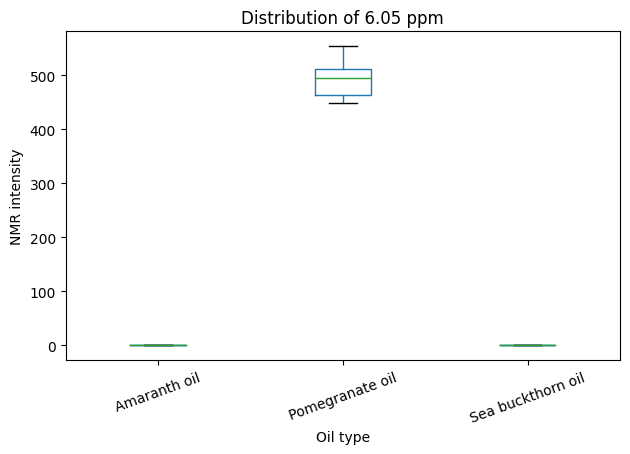

<Figure size 700x400 with 0 Axes>

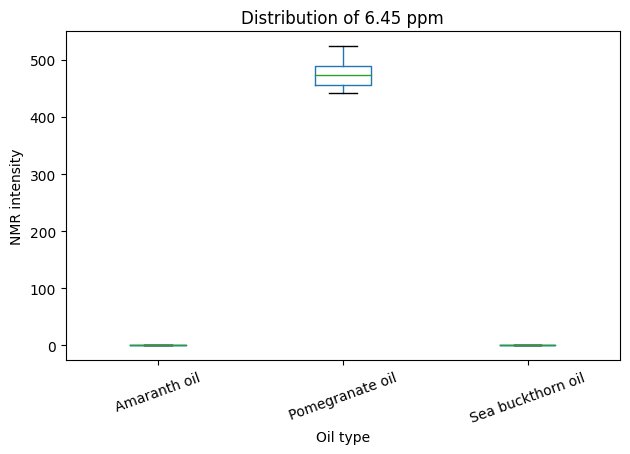

In [48]:
#import matplotlib.pyplot as plt

selected_ppm = ["0.88 ppm", "1.31 ppm", "1.36 ppm", "2.19 ppm", "5.43 ppm", "6.05 ppm", "6.45 ppm"]

for column in selected_ppm:
    plt.figure(figsize=(7, 4))

    data_v1.boxplot(column=column, by="Oil type", grid=False)

    plt.title(f"Distribution of {column}")
    plt.suptitle("")
    plt.xlabel("Oil type")
    plt.ylabel("NMR intensity")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

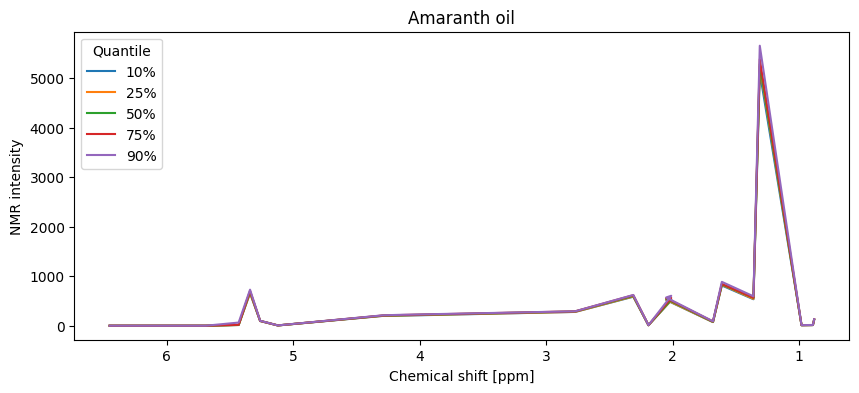

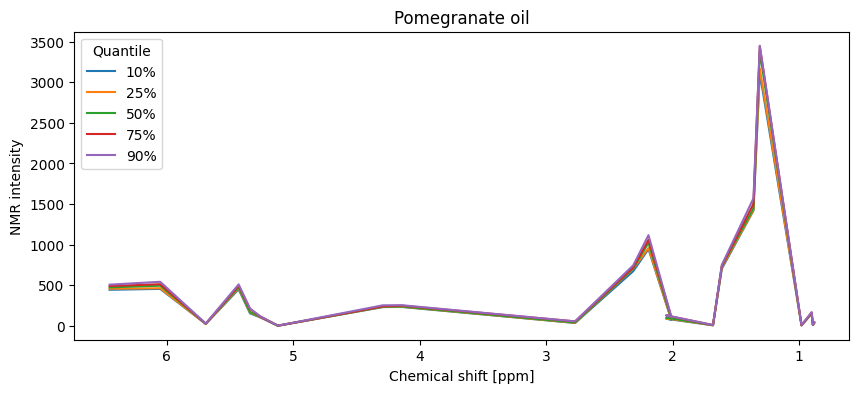

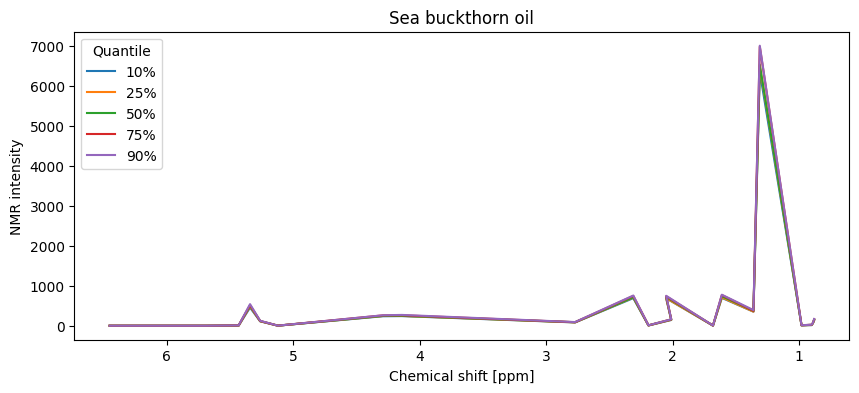

In [49]:
#import matplotlib.pyplot as plt

x = [float(col.replace(" ppm", "")) for col in nmr_columns]
levels = [0.10, 0.25, 0.50, 0.75, 0.90]

for oil, group in data_v1.groupby("Oil type"):
    q = group[nmr_columns].quantile(levels)

    plt.figure(figsize=(10, 4))

    for level in levels:
        plt.plot(x, q.loc[level], label=f"{int(level * 100)}%")

    plt.title(oil)
    plt.xlabel("Chemical shift [ppm]")
    plt.ylabel("NMR intensity")
    plt.gca().invert_xaxis()
    plt.legend(title="Quantile")
    plt.show()

**Note**: The quantiles fo specific group have differences in NMR intensity profiles among the three oil types. Pomegranate oil is particularly distinguished by high intensities at 2.19, 5.43, 6.05 and 6.45 ppm, while sea buckthorn oil shows high intensities at 0.88, 0.89, 1.31 and 2.05 ppm. Amaranth oil presents a different intermediate profile, with relatively high signals at 2.01, 2.77 and 5.34 ppm. These variables may be useful for distinguishing the oil types in subsequent multivariate analysis.

## 8. Potential outliers:

## 8.1 Tukey's fences

In [50]:
def tukeys_fences(df, k):
    """
    Detects outliers using Tukey's fences (IQR method).
    Returns a DataFrame of boolean values indicating outliers
    and a dictionary containing lower and upper fences.
    """
    outliers = pd.DataFrame(False, index=df.index, columns=df.columns)
    fences = {}

    for col in df.columns:
        if pd.api.types.is_numeric_dtype(df[col]):
            col_data = df[col].astype(float)
            q1 = col_data.quantile(0.25)
            q3 = col_data.quantile(0.75)
            iqr = q3 - q1

            lower_fence = q1 - k * iqr
            upper_fence = q3 + k * iqr

            fences[col] = [float(lower_fence), float(upper_fence)]
            mask = (col_data < lower_fence) | (col_data > upper_fence)
            outliers[col] = mask

    return outliers, fences

In [51]:
tukey_results = {}

for group_name, group_data in grouped_dfs.items():
    outliers, fences = tukeys_fences(group_data[nmr_columns], k=1.5)  #also check k=2 or 3
    tukey_results[group_name] = {"outliers": outliers, "fences": fences}
# counts the number of outliers in each column 
# .sum() - sums the number of True values (outliers) in each column
    outlier_percent = (outliers.sum() / outliers.shape[0] * 100).sort_values(ascending=False)

    print(f"\nPotential outliers for {group_name} (% of samples):")
    display(outlier_percent[outlier_percent > 0].to_frame("outlier_percent"))


Potential outliers for Amaranth oil (% of samples):


,outlier_percent
1.31 ppm,26.0
1.61 ppm,26.0
5.69 ppm,20.0
0.89 ppm,18.0
0.90 ppm,16.0
5.43 ppm,14.0
2.19 ppm,6.0



Potential outliers for Pomegranate oil (% of samples):


,outlier_percent
5.12 ppm,38.775510
2.31 ppm,32.653061
0.98 ppm,32.653061
4.29 ppm,20.408163
1.36 ppm,8.163265
1.61 ppm,8.163265



Potential outliers for Sea buckthorn oil (% of samples):


,outlier_percent
0.88 ppm,6.0
2.77 ppm,6.0
1.36 ppm,6.0
5.34 ppm,6.0
5.26 ppm,6.0
2.05 ppm,6.0
5.12 ppm,6.0
4.14 ppm,6.0


In [52]:
#fences

These values were treated as **potential** outliers. They were inspected, but not automatically removed, because extreme NMR intensities may represent genuine chemical differences between oil types.

In [53]:
outliers, fances = tukeys_fences(data_ao, k=3)

In [54]:
#We can check outliers and data for 0.89ppm
data_ao.loc[outliers['0.89 ppm']]['0.89 ppm']

1     12.61
24    12.64
27    12.66
44    12.56
47    12.64
Name: 0.89 ppm, dtype: float64

### 8.2 MAD

In [55]:
def mad_outlier_detection(df, threshold): 
    """MAD outlier detection using modified Z-scores."""
    outliers = pd.DataFrame(False, index=df.index, columns=df.columns)

    for col in df.columns:
        if pd.api.types.is_numeric_dtype(df[col]):
            series = df[col].astype(float)
            median = np.nanmedian(series)
            mad = np.nanmedian(np.abs(series - median))

            if mad == 0 or np.isnan(mad):
                outliers[col] = False
            else:
                modified_z = 0.6745 * np.abs(series - median) / mad
                outliers[col] = modified_z > threshold

    return outliers

In [56]:
mad_results = {}

for group_name, group_data in grouped_dfs.items():
    outliers = mad_outlier_detection(group_data[nmr_columns], threshold=3.5) #also check treshold 1.5 or 2
    mad_results[group_name] = outliers

    outlier_percent = (outliers.sum() / outliers.shape[0] * 100).sort_values( ascending=False )

    print(f"\nMAD potential outliers for {group_name} (% of samples):")
    display(outlier_percent[outlier_percent > 0].to_frame("outlier_percent"))


MAD potential outliers for Amaranth oil (% of samples):


,outlier_percent
0.89 ppm,26.0
0.90 ppm,16.0
1.61 ppm,16.0
5.43 ppm,14.0
2.19 ppm,6.0
2.01 ppm,2.0



MAD potential outliers for Pomegranate oil (% of samples):


,outlier_percent
2.31 ppm,28.571429
4.29 ppm,20.408163
1.36 ppm,8.163265
5.12 ppm,8.163265
4.14 ppm,8.163265
0.98 ppm,6.122449



MAD potential outliers for Sea buckthorn oil (% of samples):


,outlier_percent
5.69 ppm,30.0
4.14 ppm,6.0
0.90 ppm,6.0
1.31 ppm,6.0
1.68 ppm,6.0
5.34 ppm,6.0
5.12 ppm,6.0
4.29 ppm,6.0
2.77 ppm,6.0


In [57]:
outs = mad_outlier_detection(data_ao, threshold=3.5)
data_ao.loc[outs['0.89 ppm']]['0.89 ppm']

0     15.67
1     12.61
3     13.89
10    13.91
18    13.85
24    12.64
27    12.66
29    15.68
32    15.62
35    13.90
44    12.56
45    13.92
47    12.64
Name: 0.89 ppm, dtype: float64

**Note**: best parameters: Tukey: k = 3 for Amaranth i Sea buckthorn, Tukey: k = 2 dla Pomegranate and MAD: threshold = 3.5

- Current results point to potential outliers but do not confirm them. In particular, instances where 20-30% of the group is flagged may indicate an asymmetric or multimodal signal distribution rather than isolated erroneous measurements.

### 9. impute missing NMR measurements with `KNNImputer`.

####    Defining model
1. what type of missing values, how they gonna be mark in dataset 
2. take the best strategy (like mean,median itd)

Only NMR intensity columns are supplied to the imputer here. Sample identifiers, metadata and the target label `Oil type` are not used to calculate nearest neighbours.

If we have more than 40% of missing values we can drop it 

In [58]:
missing_percent = data_v1[nmr_columns].isna().mean() * 100

ppm_over_40 = missing_percent[missing_percent > 40]

display(ppm_over_40)

Series([], dtype: float64)

**Note**: We can have NaN because detection in NMR is below 0.2 ppm => missing not at random 

In [63]:
missing_nmr = pd.DataFrame({"missing_count": data_v1[nmr_columns].isna().sum(),
                            "missing_percent": data_v1[nmr_columns].isna().mean() * 100 }
                            ).sort_values("missing_percent", ascending=False)

missing_nmr[missing_nmr["missing_count"] > 0]

,missing_count,missing_percent
6.45 ppm,54,36.241611
5.12 ppm,17,11.409396
2.77 ppm,8,5.369128
0.88 ppm,6,4.026846
5.26 ppm,5,3.355705
1.61 ppm,4,2.684564
0.90 ppm,4,2.684564


In [64]:
missing_by_oil = (data_v1.groupby("Oil type")[nmr_columns].apply(lambda group: group.isna().mean() * 100))

missing_by_oil

,0.88 ppm,0.89 ppm,0.90 ppm,0.98 ppm,1.31 ppm,1.36 ppm,1.61 ppm,1.68 ppm,2.05 ppm,2.01 ppm,2.19 ppm,2.31 ppm,2.77 ppm,4.14 ppm,4.29 ppm,5.12 ppm,5.26 ppm,5.34 ppm,5.43 ppm,5.69 ppm,6.05 ppm,6.45 ppm
Oil type,,,,,,,,,,,,,,,,,,,,,,
Amaranth oil,12.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,16.0,0.0,0.0,10.000000,10.0,0.0,0.0,0.0,0.0,24.0
Pomegranate oil,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8.163265,0.0,0.0,0.0,0.0,0.0,0.0
Sea buckthorn oil,0.0,0.0,8.0,0.0,0.0,0.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,16.000000,0.0,0.0,0.0,0.0,0.0,84.0


SimpleImputer - fills in all missing values in a column with the same mean or median

KNNImputer - uses the most similar samples

IterativeImputer - predicts the missing value based on relationships with the other columns

### 9.1 Simple Imputer

In [65]:
from sklearn.impute import SimpleImputer
imp_simple = SimpleImputer(missing_values=np.nan, strategy='mean')
imputed_array = imp_simple.fit_transform(data_v1.select_dtypes(include=[np.number])) 
df_imputed_simple = pd.DataFrame(imputed_array, 
                                 columns=data_v1.select_dtypes(include=[np.number]).columns, 
                                 index=data_v1.select_dtypes(include=[np.number]).index)
#df_imputed_simple

In [66]:
values_below_02 = (df_imputed_simple[nmr_columns]
                    .where(df_imputed_simple[nmr_columns] < 0.2)
                    .stack()
                    .reset_index())

values_below_02.columns = ["row_index", "NMR_variable", "value"]

display(values_below_02)

,row_index,NMR_variable,value
0,0,5.69 ppm,0.17
1,0,6.05 ppm,0.14
2,1,5.69 ppm,0.16
3,1,6.05 ppm,0.13
4,2,6.05 ppm,0.13
...,...,...,...
178,147,5.69 ppm,0.11
179,147,6.05 ppm,0.19
180,148,5.69 ppm,0.13
181,149,5.69 ppm,0.09


In [67]:
results = []

for column in nmr_columns:
    mask = (data_v1[column].isna() & df_imputed_simple[column].notna())

    if mask.any():
        original_values = data_v1[column].dropna()

        results.append({"NMR column": column, "number imputed": mask.sum(),
                        "imputed value": df_imputed_simple.loc[mask, column].iloc[0], 
                        "minimum": original_values.min(), 
                        "Q1": original_values.quantile(0.25), 
                        "median": original_values.median(), 
                        "mean": original_values.mean(), 
                        "Q3": original_values.quantile(0.75), 
                        "maximum": original_values.max() })

simple_imputer_summary = pd.DataFrame(results)

display(simple_imputer_summary)

,NMR column,number imputed,imputed value,minimum,Q1,median,mean,Q3,maximum
0,0.88 ppm,6,104.570699,30.82,43.4050,125.40,104.570699,139.8850,189.04
1,0.90 ppm,4,64.523517,12.33,13.7000,22.58,64.523517,149.8400,176.14
2,1.61 ppm,4,771.649724,695.02,726.8900,754.37,771.649724,828.4200,887.45
3,2.77 ppm,8,131.470567,33.52,53.6300,86.93,131.470567,278.7400,291.94
4,5.12 ppm,17,2.987197,0.38,0.8075,1.84,2.987197,6.0175,6.77
5,5.26 ppm,5,108.673472,93.66,98.5775,110.61,108.673472,114.9475,130.09
6,6.45 ppm,54,244.641053,0.11,0.2200,442.72,244.641053,473.3650,523.94


**Note**:
- not good for our dataset because we have high volume of the missing values, particularly 6.45 ppm.
- The imputed values remain within the global observed range, but they may not represent typical values for individual oil groups
- we need to have better estimation, SimpleImputer ignores distinct oil groups -> A group-specific or detection-limit-based imputation method should therefore be considered. 
- The missing values may represent signals below the detection limit of 0.2, but SimpleImputer replaces them with much higher mean values.
- SimpleImputer may yield unreliable values because it ignores the distinct oil groups and the likely detection-limit mechanism of missingness.
- Mean imputation replaces every missing value in a given NMR variable with the same global mean, reducing the natural variability of the data.
- Global mean imputation ignores the distinct NMR profiles of the oil groups and may weaken real differences between them.
- If NaN values represent signals below the detection limit of 0.2, mean imputation is not appropriate because it replaces low censored signals with much higher values.

### 9.2 Simpler way than Simple Imputer

In [68]:
data_imputed = data_v1.copy()

# Fill missing values in selected NMR columns
data_imputed["0.88 ppm"] = data_imputed["0.88 ppm"].fillna(data_imputed["0.88 ppm"].mean())
data_imputed["0.90 ppm"] = data_imputed["0.90 ppm"].fillna(data_imputed["0.90 ppm"].median())
data_imputed["1.61 ppm"] = data_imputed["1.61 ppm"].fillna(data_imputed["1.61 ppm"].quantile(0.25))
data_imputed["2.77 ppm"] = data_imputed["2.77 ppm"].fillna(data_imputed["2.77 ppm"].mean())
data_imputed["5.12 ppm"] = data_imputed["5.12 ppm"].fillna(data_imputed["5.12 ppm"].median())
data_imputed["5.26 ppm"] = data_imputed["5.26 ppm"].fillna(data_imputed["5.26 ppm"].quantile(0.25))

In [69]:
results = []

for column in selected_ppm:
    mask = (data_v1[column].isna() & data_imputed[column].notna())

    if mask.any():
        original_values = data_v1[column].dropna()

        results.append({"NMR column": column,
                        "number imputed": mask.sum(), 
                        "imputed value": data_imputed.loc[mask,column].iloc[0], 
                        "minimum": original_values.min(), 
                        "Q1": original_values.quantile(0.25), 
                        "median": original_values.median(), 
                        "Q3": original_values.quantile(0.75),
                        "maximum": original_values.max()})

distribution_comparison = pd.DataFrame(results)

display(distribution_comparison)

,NMR column,number imputed,imputed value,minimum,Q1,median,Q3,maximum
0,0.88 ppm,6,104.570699,30.82,43.405,125.4,139.885,189.04


**Note**:
- Manual imputation gives more control because the method can be chosen separately for each NMR variable.
- Median and Q1 are more robust than the mean for skewed distributions and high values.
- For `0.88 ppm` and `2.77 ppm`, the result is the same as mean-based SimpleImputer.
- The method still assigns the same value to every missing observation in a column and reduces variability.
- It also ignores differences between oil types.
- If `NaN` means a signal below the detection limit, even median or Q1 imputation may still be too high.


### 9.3 KNN Imputer

In [70]:
from sklearn.impute import KNNImputer

imputed_groups = []

for oil_type, group in data_v1.groupby("Oil type"):
    group_imputed = group.copy()

    imputer = KNNImputer(n_neighbors=3)
    group_imputed[nmr_columns] = imputer.fit_transform(group[nmr_columns])
    imputed_groups.append(group_imputed)

knn_df_imputed = pd.concat(imputed_groups).sort_index()

In [71]:
results = []

for oil_type, original_group in data_v1.groupby("Oil type"):
    
    # Use the dataset imputed with KNN
    imputed_group = knn_df_imputed.loc[original_group.index]

    for column in nmr_columns:
        mask = (original_group[column].isna() & imputed_group[column].notna())

        if mask.any():
            original_values = original_group[column].dropna()

            imputed_counts = (imputed_group.loc[mask, column] .round(4) .value_counts())

            for imputed_value, count in imputed_counts.items():
                results.append({"Oil type": oil_type, 
                                "NMR column": column, 
                                "imputed value": imputed_value, 
                                "number of occurrences": count, 
                                "minimum": original_values.min(), 
                                "Q1": original_values.quantile(0.25),
                                "median": original_values.median(), 
                                "Q3": original_values.quantile(0.75), 
                                "maximum": original_values.max() })

knn_imputer_summary = pd.DataFrame(results).round(4)

#display(knn_imputer_summary)

**Note**:
- KNN imputation preserves more variability than global mean imputation.
- Here missing values are higher than limit of the detection (most of them)
- Most KNN estimates remain within the observed ranges and are often closer to the median or oil-specific pattern.
- NN clearly improves the results for 0.90 ppm and especially 6.45 ppm, where global mean imputation produced an artificial intermediate value.
- The estimate for 2.77 ppm is close to the observed maximum and should be reviewed.
- Variables with many missing values, particularly 6.45 ppm, remain highly uncertain.
- Scaling and oil-specific imputation should be applied before using KNN.

### 9.4 IterativeImputer - (as like MICE - Multiple Imputation by Chained Equations)
It's is inspired but not true MICE (sample_posterior=True) <br>
IterativeImputer  models each feature with missing values as a function of other features, and uses that estimate for imputation. 

In [72]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
import pandas as pd

imputed_groups = []

for oil_type, oil_data in data_v1.groupby("Oil type"):

    # Only NMR columns that contain at least one observed value
    columns_to_impute = [column for column in nmr_columns if oil_data[column].notna().any()]

    # Keep only identifiers and NMR variables
    oil_imputed = oil_data[["Primary ID", "Oil type"] + nmr_columns].copy()

    imp_miceish = IterativeImputer(max_iter=10, random_state=42, min_value=0)

    imputed_array = imp_miceish.fit_transform(oil_data[columns_to_impute])

    oil_imputed[columns_to_impute] = imputed_array

    imputed_groups.append(oil_imputed)

# Combine oil groups and restore original row order
ii_imputed_data_v1 = (pd.concat(imputed_groups) .sort_index())

#display(ii_imputed_data_v1)

### 9.5 SUM UP all Imputers

In [73]:
results = []

for column in nmr_columns:
    
    # Select rows where the original value was missing
    missing_mask = data_v1[column].isna()

    for row_index in data_v1.index[missing_mask]:
        results.append({"Primary ID": data_v1.loc[row_index,"Primary ID"],
                        "Oil type": data_v1.loc[row_index, "Oil type"], 
                        "NMR column": column, 
                        "Simple imputed value": df_imputed_simple.loc[row_index, column], 
                        "KNN imputed value": knn_df_imputed.loc[row_index, column], 
                        "Iterative imputed value": ii_imputed_data_v1.loc[row_index,column]})

imputation_comparison_by_id = (pd.DataFrame(results)
                               .sort_values(["NMR column","Primary ID"]) 
                               .reset_index(drop=True) 
                               .round(4))

display(imputation_comparison_by_id)

,Primary ID,Oil type,NMR column,Simple imputed value,KNN imputed value,Iterative imputed value
0,8,Amaranth oil,0.88 ppm,104.5707,128.7633,129.8170
1,12,Amaranth oil,0.88 ppm,104.5707,128.7633,129.6895
2,17,Amaranth oil,0.88 ppm,104.5707,128.7633,129.9745
3,20,Amaranth oil,0.88 ppm,104.5707,128.7633,130.1039
4,21,Amaranth oil,0.88 ppm,104.5707,128.7633,129.6658
5,26,Amaranth oil,0.88 ppm,104.5707,128.8067,129.6257
6,106,Sea buckthorn oil,0.90 ppm,64.5235,22.5467,22.5020
7,125,Sea buckthorn oil,0.90 ppm,64.5235,22.5467,23.0487
8,129,Sea buckthorn oil,0.90 ppm,64.5235,22.5633,22.1828
9,134,Sea buckthorn oil,0.90 ppm,64.5235,22.5467,21.8088


**Note**:
- SimpleImputer produced constant global estimates and did not account for oil-specific patterns.
- KNNImputer generated more realistic values based on similar samples within each oil group.
- IterativeImputer produced sample-specific estimates, but occasionally extrapolated beyond the observed range.
- Based on the current results, KNNImputer appears to be the safest primary method, while IterativeImputer can be used as a sensitivity analysis.
- The final method should be selected using validation on artificially masked observed values

## 9.6 Assemble the processed dataset

The original metadata are combined with the imputed NMR measurements. The original row order and identifiers are preserved.

In [74]:
processed_data = data_v1.copy()

processed_data[nmr_columns] = knn_df_imputed[nmr_columns]

processed_data.head()

,Primary ID,Date,Oil type,Manufacturer,Batch number,Spectra number,0.88 ppm,0.89 ppm,0.90 ppm,0.98 ppm,1.31 ppm,1.36 ppm,1.61 ppm,1.68 ppm,2.05 ppm,2.01 ppm,2.19 ppm,2.31 ppm,2.77 ppm,4.14 ppm,4.29 ppm,5.12 ppm,5.26 ppm,5.34 ppm,5.43 ppm,5.69 ppm,6.05 ppm,6.45 ppm
0,1,"October 07, 2025",Amaranth oil,A,43739,1,125.47,15.67,12.34,11.18,5306.83,565.27,837.44,73.93,537.41,526.74,12.03,605.74,289.95,212.43,207.07,6.50,98.21,690.85,15.09,0.17,0.14,0.34
1,2,"October 07, 2025",Amaranth oil,A,43739,2,118.10,12.61,13.60,10.30,4961.43,543.99,798.57,73.89,493.14,559.02,10.17,576.95,278.62,202.45,200.15,6.18,93.73,657.26,14.80,0.16,0.13,0.34
2,3,"October 08, 2025",Amaranth oil,A,43739,3,120.78,14.86,12.87,10.92,5138.00,565.93,828.82,72.39,523.22,511.93,10.83,593.72,288.63,204.00,204.26,6.55,95.49,674.88,16.99,0.23,0.13,0.32
3,4,"October 10, 2025",Amaranth oil,B,43466,4,123.53,13.89,13.74,10.57,5255.57,534.17,828.79,85.30,532.51,511.78,10.76,586.82,281.73,207.87,197.60,5.95,95.18,658.60,14.73,0.13,0.10,0.25
4,5,2025-11-02,Amaranth oil,B,43466,5,131.93,14.88,15.07,11.60,5660.95,594.31,886.85,88.52,570.69,605.27,11.31,621.07,291.22,221.07,210.26,6.17,98.52,702.16,19.60,0.14,0.21,0.22


## 10 Validate, standarize and save the processed dataset.

In [75]:
# Save information about dates that were originally present
original_date_mask = processed_data["Date"].notna()

# Convert mixed date formats to datetime
parsed_dates = pd.to_datetime(processed_data["Date"], format="mixed", dayfirst=True, errors="coerce")

# Check whether all non-missing dates were converted correctly
assert parsed_dates[original_date_mask].notna().all(), \
    "Some date values could not be converted."

# Standardize date format to YYYY-MM-DD
processed_data["Date"] = parsed_dates.dt.strftime("%Y-%m-%d")

# Standardize batch numbers as text
processed_data["Batch number"] = (processed_data["Batch number"] .astype("string") .str.strip())

# Replace text indicating missing data with pandas missing value
processed_data.loc[ processed_data["Batch number"].str.lower().eq("no data"), "Batch number"] = pd.NA

# Final dataset validation
assert processed_data[nmr_columns].isna().sum().sum() == 0, \
    "Missing values remain in the NMR columns."

assert processed_data.shape[0] == data_v1.shape[0], \
    "The number of rows has changed."

assert processed_data["Oil type"].equals(data_v1["Oil type"]), \
    "Oil type values or their order have changed."

assert processed_data["Date"].dropna().str.match( r"^\d{4}-\d{2}-\d{2}$").all(), \
    "Dates are not in the YYYY-MM-DD format."

assert processed_data["Batch number"].dtype == "string", \
    "Batch number is not stored as text."

print("Validation passed.")
print("No missing values remain in the NMR variables.")
print("Oil labels and the number of records were preserved.")
print("Dates were standardized to YYYY-MM-DD.")
print("Batch numbers were standardized as text.")
print("Missing batch numbers were converted to pd.NA.")

Validation passed.
No missing values remain in the NMR variables.
Oil labels and the number of records were preserved.
Dates were standardized to YYYY-MM-DD.
Batch numbers were standardized as text.
Missing batch numbers were converted to pd.NA.


In [76]:
OUTPUT_PATH = Path("data") / "processed" / "oils_processed.csv"

# Create the directory if it does not exist
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)

processed_data.to_csv(OUTPUT_PATH, index=False)

print(f"Processed dataset saved to: {OUTPUT_PATH}")
print(f"Saved shape: {processed_data.shape}")

Processed dataset saved to: data/processed/oils_processed.csv
Saved shape: (149, 28)


In [77]:
#Saving figures
from pathlib import Path

PROJECT_DIR =Path(".")
FIGURES_DIR = PROJECT_DIR / "diagrams" / "01"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(FIGURES_DIR)

diagrams/01


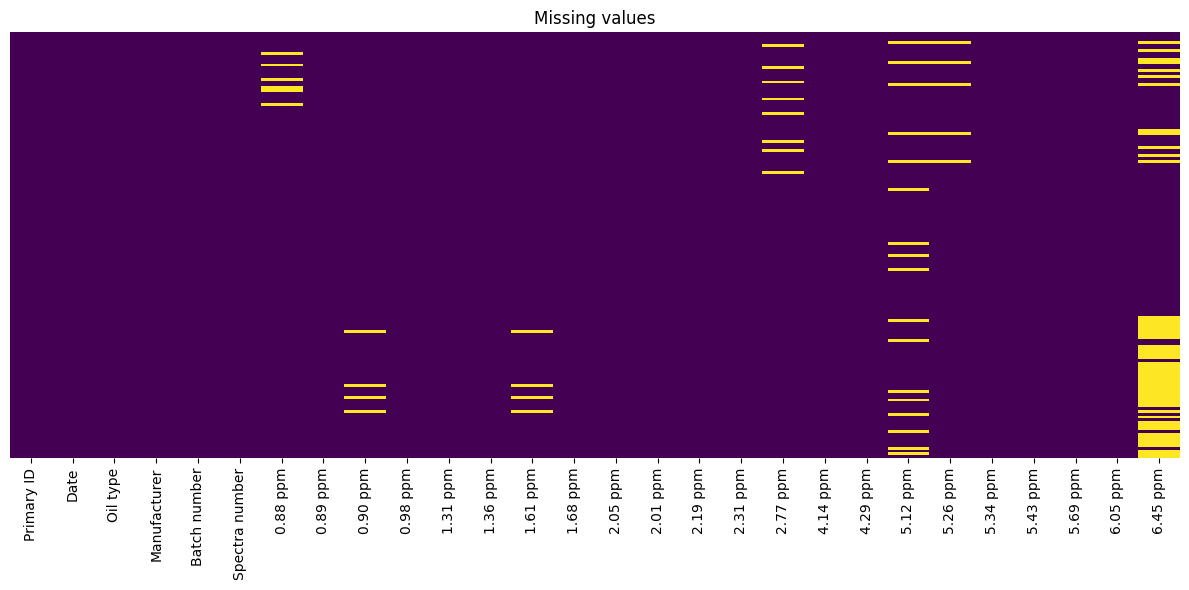

In [78]:
plt.figure(figsize=(12, 6))

sns.heatmap( data.isnull(), cbar=False, cmap="viridis", yticklabels=False)

plt.title("Missing values")

plt.tight_layout()

plt.savefig( FIGURES_DIR / "missing_values_heatmap.png", dpi=300, bbox_inches="tight")

plt.show()

## Summary

The processed dataset:

- contains one copy of each analytical record,
- retains sample metadata and oil-type labels,
- preserves potential extreme values for later interpretation,
- contains no missing NMR intensities after KNN imputation,
- is ready for the SQL and multivariate-analysis notebooks.